In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set()

In [2]:
df = pd.read_csv("data/raw_dataset.csv") 
df.head()

,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0


In [3]:
print(df.shape)
df.info()
df.isnull().sum()

(17880, 18)
<class 'pandas.DataFrame'>
RangeIndex: 17880 entries, 0 to 17879
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   job_id               17880 non-null  int64
 1   title                17880 non-null  str  
 2   location             17534 non-null  str  
 3   department           6333 non-null   str  
 4   salary_range         2868 non-null   str  
 5   company_profile      14572 non-null  str  
 6   description          17879 non-null  str  
 7   requirements         15184 non-null  str  
 8   benefits             10668 non-null  str  
 9   telecommuting        17880 non-null  int64
 10  has_company_logo     17880 non-null  int64
 11  has_questions        17880 non-null  int64
 12  employment_type      14409 non-null  str  
 13  required_experience  10830 non-null  str  
 14  required_education   9775 non-null   str  
 15  industry             12977 non-null  str  
 16  function             

job_id                     0
title                      0
location                 346
department             11547
salary_range           15012
company_profile         3308
description                1
requirements            2696
benefits                7212
telecommuting              0
has_company_logo           0
has_questions              0
employment_type         3471
required_experience     7050
required_education      8105
industry                4903
function                6455
fraudulent                 0
dtype: int64

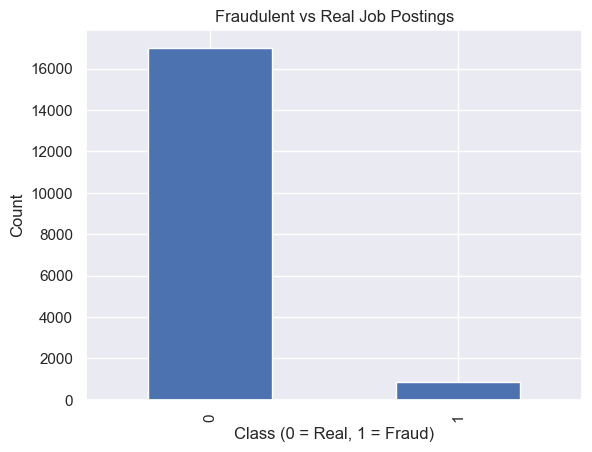

In [4]:
df['fraudulent'].value_counts().plot(kind='bar')
plt.title("Fraudulent vs Real Job Postings")
plt.xlabel("Class (0 = Real, 1 = Fraud)")
plt.ylabel("Count")
plt.show()

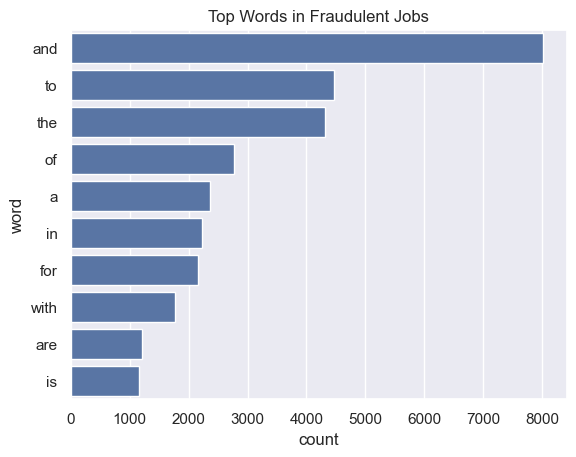

In [5]:
from collections import Counter
import re

fraud_text = " ".join(df[df['fraudulent'] == 1]['description'].dropna())

words = re.findall(r'\w+', fraud_text.lower())
common_words = Counter(words).most_common(10)

words_df = pd.DataFrame(common_words, columns=['word', 'count'])

sns.barplot(x='count', y='word', data=words_df)
plt.title("Top Words in Fraudulent Jobs")
plt.show()

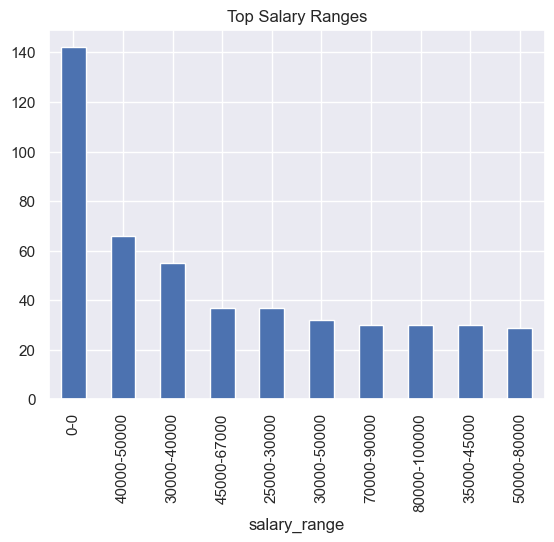

In [6]:
if 'salary_range' in df.columns:
    df['salary_range'].value_counts().head(10).plot(kind='bar')
    plt.title("Top Salary Ranges")
    plt.show()

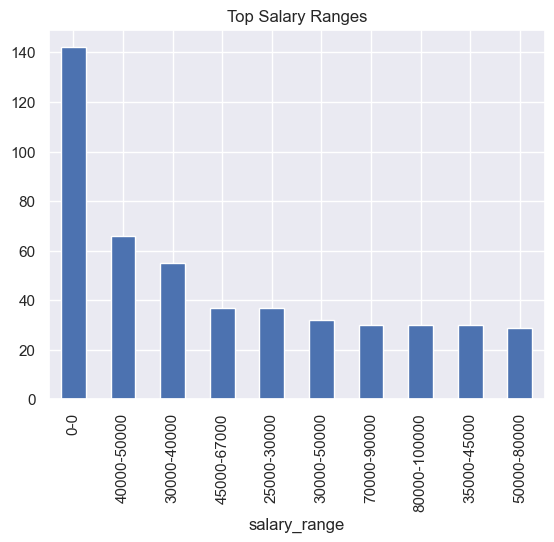

In [7]:
if 'salary_range' in df.columns:
    df['salary_range'].value_counts().head(10).plot(kind='bar')
    plt.title("Top Salary Ranges")
    plt.show()

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\KARNIKA\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\KARNIKA\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\KARNIKA\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
c:\Users\KARNIKA\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


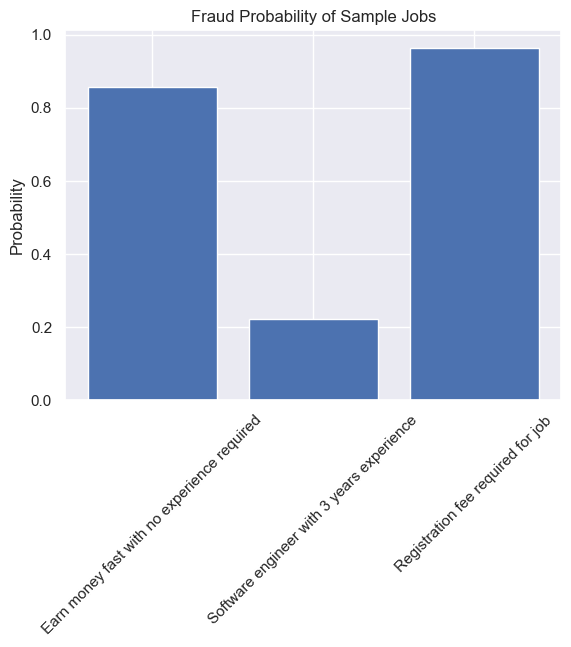

In [8]:
import sys
import os
sys.path.append(os.path.abspath("."))

import matplotlib.pyplot as plt
from backend.predictor import predict_single

sample_jobs = [
    "Earn money fast with no experience required",
    "Software engineer with 3 years experience",
    "Registration fee required for job"
]

results = []

for text in sample_jobs:
    result, _ = predict_single(
        title="",
        description=text,
        company_profile="",
        requirements=""
    )
    results.append(result['fraud_probability'])

plt.bar(sample_jobs, results)
plt.xticks(rotation=45)
plt.title("Fraud Probability of Sample Jobs")
plt.ylabel("Probability")
plt.show()

In [9]:
# =========================
# MODEL TRAINING + ACCURACY
# =========================

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from ml_pipeline.model_training import train_models, evaluate_model

# 🔹 Combine text fields (same as your pipeline)
df['combined_text'] = (
    df['description'].fillna('') + " " +
    df.get('requirements', '').fillna('') + " " +
    df.get('company_profile', '').fillna('')
)

# 🔹 Features & Labels
X_text = df['combined_text']
y = df['fraudulent']

# 🔹 Convert text → TF-IDF
vectorizer = TfidfVectorizer(max_features=5000)
X = vectorizer.fit_transform(X_text)

# 🔹 Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 🔹 Train models
models = train_models(X_train, y_train)

# 🔹 Evaluate models
results = {}

for name, model in models.items():
    metrics = evaluate_model(model, X_test, y_test)
    results[name] = metrics

# 🔹 Convert to DataFrame
results_df = pd.DataFrame(results).T
print("Model Performance:\n")
display(results_df)

c:\Users\KARNIKA\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
c:\Users\KARNIKA\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:200: UserWarning: [21:54:24] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Model Performance:



,accuracy,precision,recall,f1,roc_auc
logistic_regression,0.970638,0.987179,0.425414,0.594595,0.965490
random_forest,0.979586,0.990909,0.602210,0.749141,0.977998
xgboost,0.981264,0.967213,0.651934,0.778878,0.980799


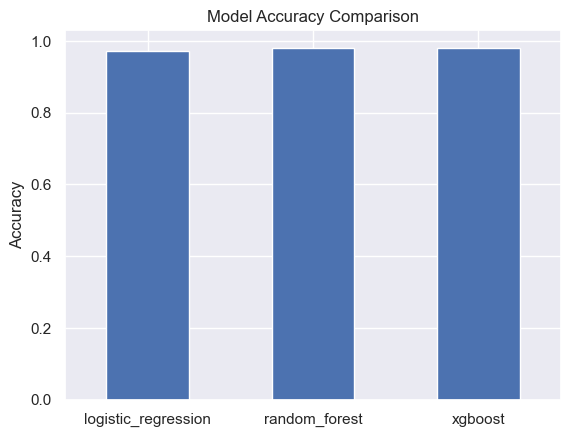

In [10]:
results_df['accuracy'].plot(kind='bar')
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=0)
plt.show()

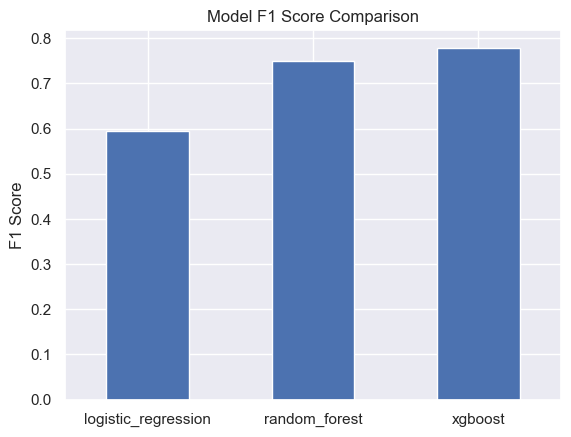

In [11]:
results_df['f1'].plot(kind='bar')
plt.title("Model F1 Score Comparison")
plt.ylabel("F1 Score")
plt.xticks(rotation=0)
plt.show()

In [12]:

best_model = results_df['f1'].idxmax()
print("Best Model based on F1 Score:", best_model)

Best Model based on F1 Score: xgboost


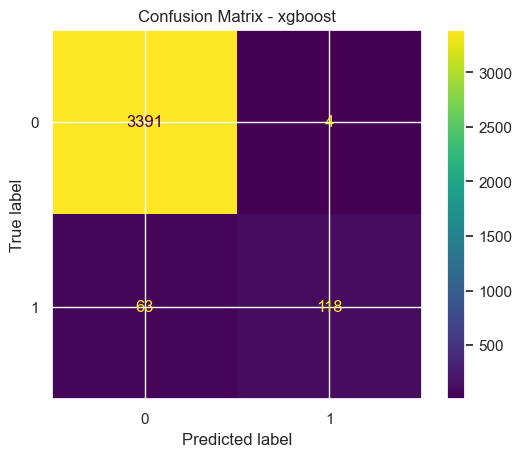

In [13]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 🔹 Choose best model (or use xgboost directly)
best_model_name = results_df['f1'].idxmax()
best_model = models[best_model_name]

# 🔹 Predictions
y_pred = best_model.predict(X_test)

# 🔹 Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title(f"Confusion Matrix - {best_model_name}")
plt.show()

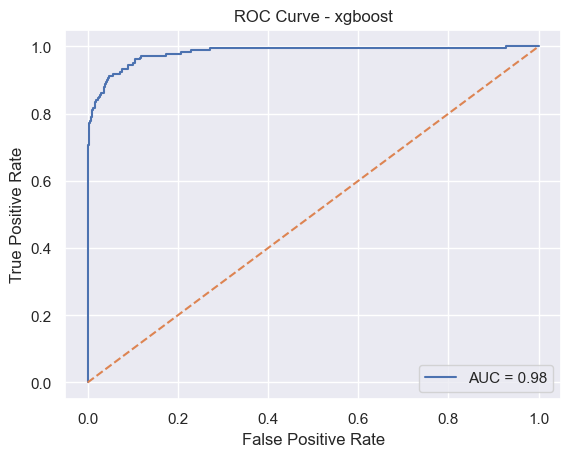

In [14]:
from sklearn.metrics import roc_curve, auc

# 🔹 Get probability scores
y_proba = best_model.predict_proba(X_test)[:, 1]

# 🔹 ROC values
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

# 🔹 Plot
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve - {best_model_name}")
plt.legend()
plt.show()